# Replay & Analytics Dashboard

Historical replay simulation and institutional-grade performance analytics.

> **Prerequisite:** Run `main_mean_reversion.ipynb` first to generate bridge data.


In [1]:
# ============================================================================
# LOAD BRIDGE DATA — from core backtest notebook
# ============================================================================
import gc
gc.collect()

%load_ext autoreload
%autoreload 2

import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Resolve project root
project_root = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

from strategy_config import ConfigLoader
from backtest.engine import BacktestEngine, BacktestConfig, calculate_rolling_sharpe, calculate_underwater_curve

# Load bridge data
_bridge_path = project_root / 'data' / 'snapshots' / 'notebook_bridge' / 'core_results.pkl'
with open(_bridge_path, 'rb') as f:
    _bridge = pickle.load(f)

results = _bridge['results']
bt_config = _bridge['bt_config']
config = ConfigLoader(Path(_bridge['config_path']))
price_df = _bridge['price_df']
signal_df = _bridge['signal_df']
volume_df = _bridge['volume_df']
zscore_df = _bridge['zscore_df']
analysis_df = _bridge['analysis_df']
all_data = _bridge['all_data']

del _bridge
gc.collect()

print('✓ Bridge data loaded successfully')
print(f'  Symbols: {len(signal_df.columns)}')
print(f'  Date range: {signal_df.index.min()} → {signal_df.index.max()}')
print(f'  Backtest trades: {results.total_trades}')


✓ Bridge data loaded successfully
  Symbols: 216
  Date range: 2006-02-14 00:00:00 → 2026-02-13 00:00:00
  Backtest trades: 23988


## Phase 9: Animated Historical Replay

Replays the full trading pipeline day-by-day with **live-updating charts** and **scrolling execution logs** — replicating the VM trading experience visually.

**Features simulated:**
- Option D order flow (market entry → poll fill → standalone GTC stop)
- T1 sentiment penalty filter
- All exit types (signal, stop-loss, trailing stop, time-decay, max-holding, take-profit)
- Adaptive animation speed: quiet days fast, trade days slow (~2 min total)

> **Requires:** All cells above must be executed first (config, data, signals, backtest).

In [2]:
# ── Setup Animated Replay ──
# Cleanup previous replay widgets/state if rerunning
if 'replay' in dir() and hasattr(replay, 'cleanup'):
    replay.cleanup()
    del replay

import gc; gc.collect()

from execution.animated_replay import AnimatedReplay

# Determine replay window (last 2 years of available data)
replay_end = signal_df.index.max()
replay_start = replay_end - pd.DateOffset(years=2)
print(f"Replay window: {replay_start.strftime('%Y-%m-%d')} → {replay_end.strftime('%Y-%m-%d')}")
print(f"Trading days in range: {((signal_df.index >= replay_start) & (signal_df.index <= replay_end)).sum()}")

# Create replay engine with current config
replay = AnimatedReplay(
    config=config,
    bt_config=bt_config,
    price_df=price_df,
    signal_df=signal_df,
    volume_df=volume_df,
    zscore_df=zscore_df,
    analysis_df=analysis_df,
    initial_capital=bt_config.initial_capital,
)
print(f"\n✓ Replay engine ready")
print(f"  Capital: ${bt_config.initial_capital:,.0f}")
print(f"  Entry threshold: {bt_config.entry_threshold}")
print(f"  Stop loss: {bt_config.stop_loss_pct:.0%}" if bt_config.stop_loss_pct else "  Stop loss: Disabled")
print(f"  T1 sentiment: {'ON' if getattr(bt_config, 'sentiment_penalty_enabled', False) else 'OFF'}")
print(f"  Trailing stop: {'ON' if bt_config.use_trailing_stop else 'OFF'}")
print(f"  Time decay exit: {'ON' if bt_config.use_time_decay_exit else 'OFF'}")

Replay window: 2024-02-13 → 2026-02-13
Trading days in range: 503

✓ Replay engine ready
  Capital: $100,000
  Entry threshold: 1.0
  Stop loss: 10%
  T1 sentiment: ON
  Trailing stop: ON
  Time decay exit: ON


In [3]:
# ── Run Animated Replay ──
# fast_mode=True: ~30-60s (batched UI, no sleeps)
# fast_mode=False: ~10 min (animated day-by-day)
# Speed: 1.0 = ~2min, 0.5 = ~1min, 2.0 = ~4min (only when fast_mode=False)

replay_results, replay_sim = replay.run(
    start_date=replay_start.strftime('%Y-%m-%d'),
    end_date=replay_end.strftime('%Y-%m-%d'),
    speed_multiplier=1.0,
    fast_mode=True,
)

## Phase 10: Performance & Risk Analytics Dashboard

Institutional-grade analytics across 20 years of data.

In [4]:
# ============================================================================
# 3B — PERFORMANCE ANALYTICS (Capital, Risk, Rolling, Trade, Cost, Regime)
# ============================================================================
# ANALYTICS_MODE controls which analytics are displayed in cells below.
#   'REPLAY'   — show replay analytics only  (default when replay data exists)
#   'BACKTEST' — show backtest analytics only
#   'BOTH'     — show both side-by-side

ANALYTICS_MODE = 'REPLAY'   # ← change this to switch views

from pathlib import Path
from backtest.analytics import PerformanceAnalytics
from backtest.engine import Trade as _Trade, BacktestResults as _BacktestResults

# ── Backtest analytics ──
analytics = PerformanceAnalytics(
    results=results,
    config=bt_config,
    signal_df=signal_df,
    output_dir=project_root / 'DataAnalysisExpert',
    label='BACKTEST',
)

# ── Replay analytics (mirror backtest analytics using replay data) ──
replay_analytics = None
if replay_results and 'error' not in replay_results:
    # Build Trade objects from replay_results['trades_df'] (survives replay_sim cleanup)
    _rp_tdf = replay_results.get('trades_df')
    if _rp_tdf is not None and len(_rp_tdf) > 0:
        _replay_trades = [
            _Trade(
                symbol=row['symbol'],
                entry_date=row['entry_date'],
                exit_date=row['exit_date'],
                entry_price=row['entry_price'],
                exit_price=row['exit_price'],
                shares=row['qty'],
                side=row['side'],
                pnl=row['pnl'],
                pnl_pct=row['pnl_pct'],
                commission=row['commission'],
                holding_days=row['holding_days'],
                entry_signal=0.0,
                exit_signal=0.0,
                exit_reason=row['exit_reason'],
            )
            for _, row in _rp_tdf.iterrows()
        ]
    else:
        _replay_trades = []

    _replay_bt = _BacktestResults(
        equity_curve=replay_results['equity_curve'],
        returns=replay_results['returns'],
        trades=_replay_trades,
        total_return=replay_results['total_return_pct'] / 100,
        sharpe_ratio=replay_results['sharpe_ratio'],
        max_drawdown=replay_results['max_drawdown_pct'] / 100,
        total_trades=replay_results['total_trades'],
        win_rate=replay_results['win_rate'] / 100,
    )

    replay_analytics = PerformanceAnalytics(
        results=_replay_bt,
        config=bt_config,
        signal_df=signal_df.loc[replay_start:replay_end],
        output_dir=project_root / 'DataAnalysisExpert',
        label='REPLAY',
    )
    del _replay_trades, _replay_bt, _rp_tdf  # free intermediates

# Validate mode
_show_bt = ANALYTICS_MODE in ('BACKTEST', 'BOTH')
_show_rp = ANALYTICS_MODE in ('REPLAY', 'BOTH') and replay_analytics is not None

if not _show_bt and not _show_rp:
    # Fallback: if replay requested but unavailable, show backtest
    _show_bt = True
    print("⚠ Replay unavailable — falling back to BACKTEST mode.")

print(f"✓ Analytics mode: {ANALYTICS_MODE}")
if _show_bt and _show_rp:
    print("  Showing: BACKTEST + REPLAY")
elif _show_rp:
    print("  Showing: REPLAY only")
else:
    print("  Showing: BACKTEST only")

# 3B.0 — Capital Utilization Diagnostic
if _show_bt:
    cap_report = analytics.capital_utilization()
if _show_rp:
    rp_cap_report = replay_analytics.capital_utilization()

✓ Analytics mode: REPLAY
  Showing: REPLAY only
CAPITAL UTILIZATION DIAGNOSTIC [REPLAY]

--- Market Presence ---
  Total trading days:            503
  Days with open positions:      503 (100.0%)
  Days fully idle (0 positions): 0 (0.0%)
  Avg exposure:                  0.00%
  Max concurrent positions:      0

--- Position Sizing When Active ---
  Avg position value:    $43,849
  Avg equity at entry:   $292,942
  Avg position % equity: 14.97%
  Max position size cap: 15%
  Avg holding period:    2.1 days

--- Concurrent Positions Distribution ---
   0 positions:     0 days (  0.0%) 
   1 positions:     0 days (  0.0%) 
   2 positions:     0 days (  0.0%) 
   3 positions:     0 days (  0.0%) 
   4 positions:     1 days (  0.2%) 
   5 positions:     0 days (  0.0%) 
   6 positions:     2 days (  0.4%) 
   7 positions:    18 days (  3.6%) █
   8 positions:    31 days (  6.2%) ███
   9 positions:    88 days ( 17.5%) ████████
  10 positions:   134 days ( 26.6%) █████████████
  11 positions

In [5]:
# 3B.1 — Risk Metrics Dashboard
if _show_bt:
    risk_report = analytics.risk_metrics()
if _show_rp:
    rp_risk_report = replay_analytics.risk_metrics()

3B.1 — RISK METRICS DASHBOARD [REPLAY]

--- Value at Risk (Historical) ---
  VaR 95%: -1.3760%  (on 95% of days, daily loss < 1.3760%)
  VaR 99%: -2.8129%  (on 99% of days, daily loss < 2.8129%)

--- Conditional VaR (Expected Shortfall) ---
  CVaR 95%: -2.1478%  (avg loss on worst 5% of days)
  CVaR 99%: -3.3850%  (avg loss on worst 1% of days)

--- Tail Ratio ---
  95th percentile (gains): +2.3482%
  5th percentile (losses): -1.3760%
  Tail Ratio: 1.71x  (✓ Positive skew)

--- Distribution Shape ---
  Skewness:  1.7107  (Right-skewed (good))
  Kurtosis:  15.3813  (Leptokurtic (fat tails))
  Jarque-Bera: stat=5183.1, p=0.000000  (Non-normal)

--- Omega Ratio (threshold=0%) ---
  Omega: 2.30  (sum of gains / sum of losses, >1 = profitable)

--- Ulcer Index ---
  Ulcer Index: 1.9774%  (lower = smoother equity curve)
  Ulcer Performance Index: 0.00  (return / ulcer, higher = better)

--- Gain-to-Pain Ratio ---
  G/P Ratio: 1.30  (total gains / total losses, >1 = net profitable)

--- Daily

Saved: /workspaces/Quant/DataAnalysisExpert/3B2_rolling_analytics.png


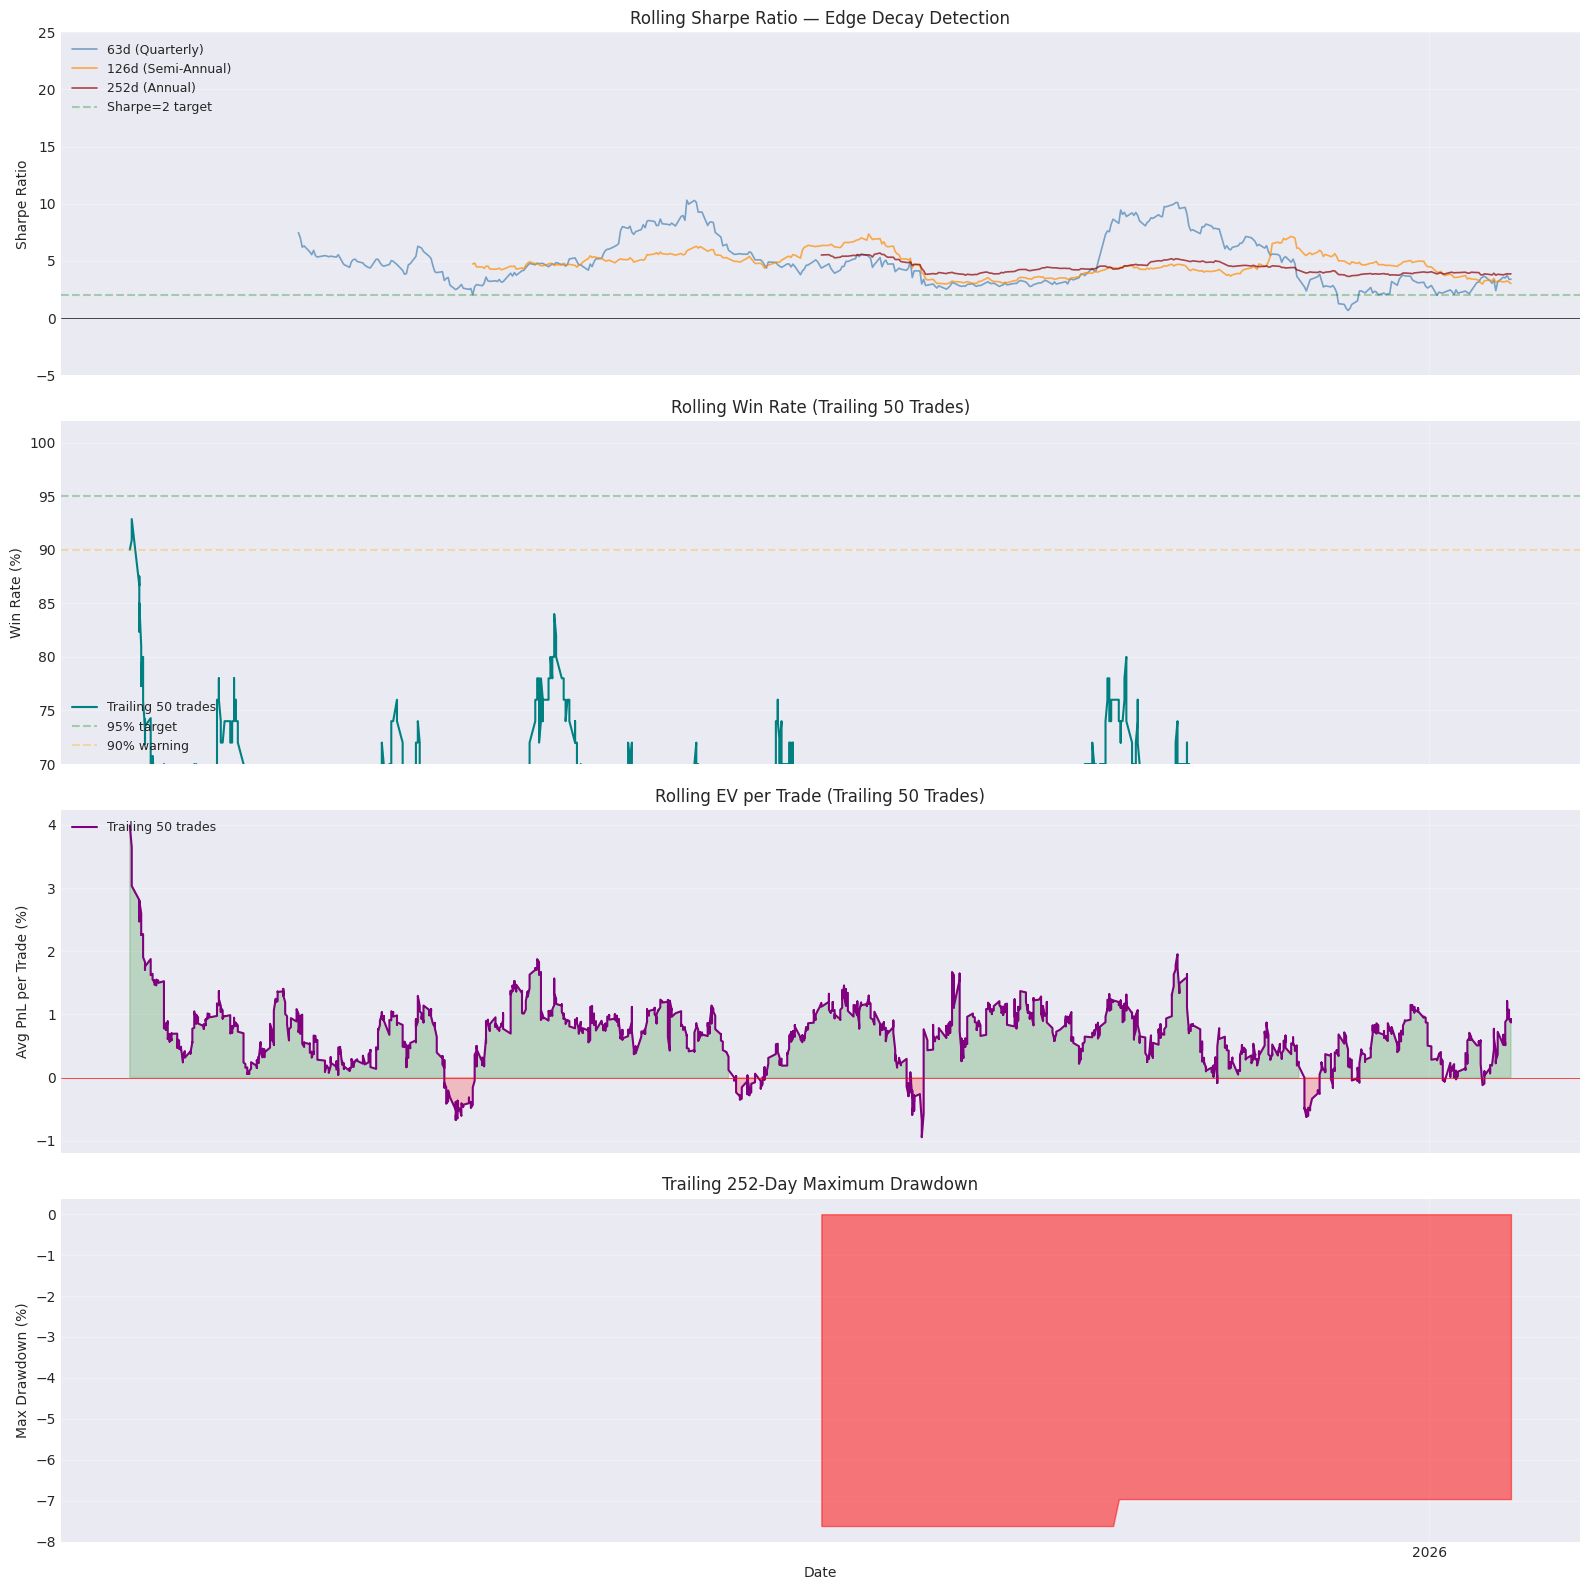

In [6]:
# 3B.2 — Rolling Analytics (Edge Decay Detection)
if _show_bt:
    analytics.rolling_analytics()
if _show_rp:
    replay_analytics.rolling_analytics()

3B.3 — TRADE-LEVEL ANALYTICS [REPLAY]

--- Win/Loss Streaks ---
  Max winning streak: 17 trades
  Avg winning streak: 2.8 trades
  Max losing streak:  11 trades
  Avg losing streak:  1.8 trades

--- Holding Period Stats ---
  Mean:   2.1 days
  Median: 1 days
  Mode:   1 days
  Max:    8 days

Saved: /workspaces/Quant/DataAnalysisExpert/3B3_trade_analytics.png


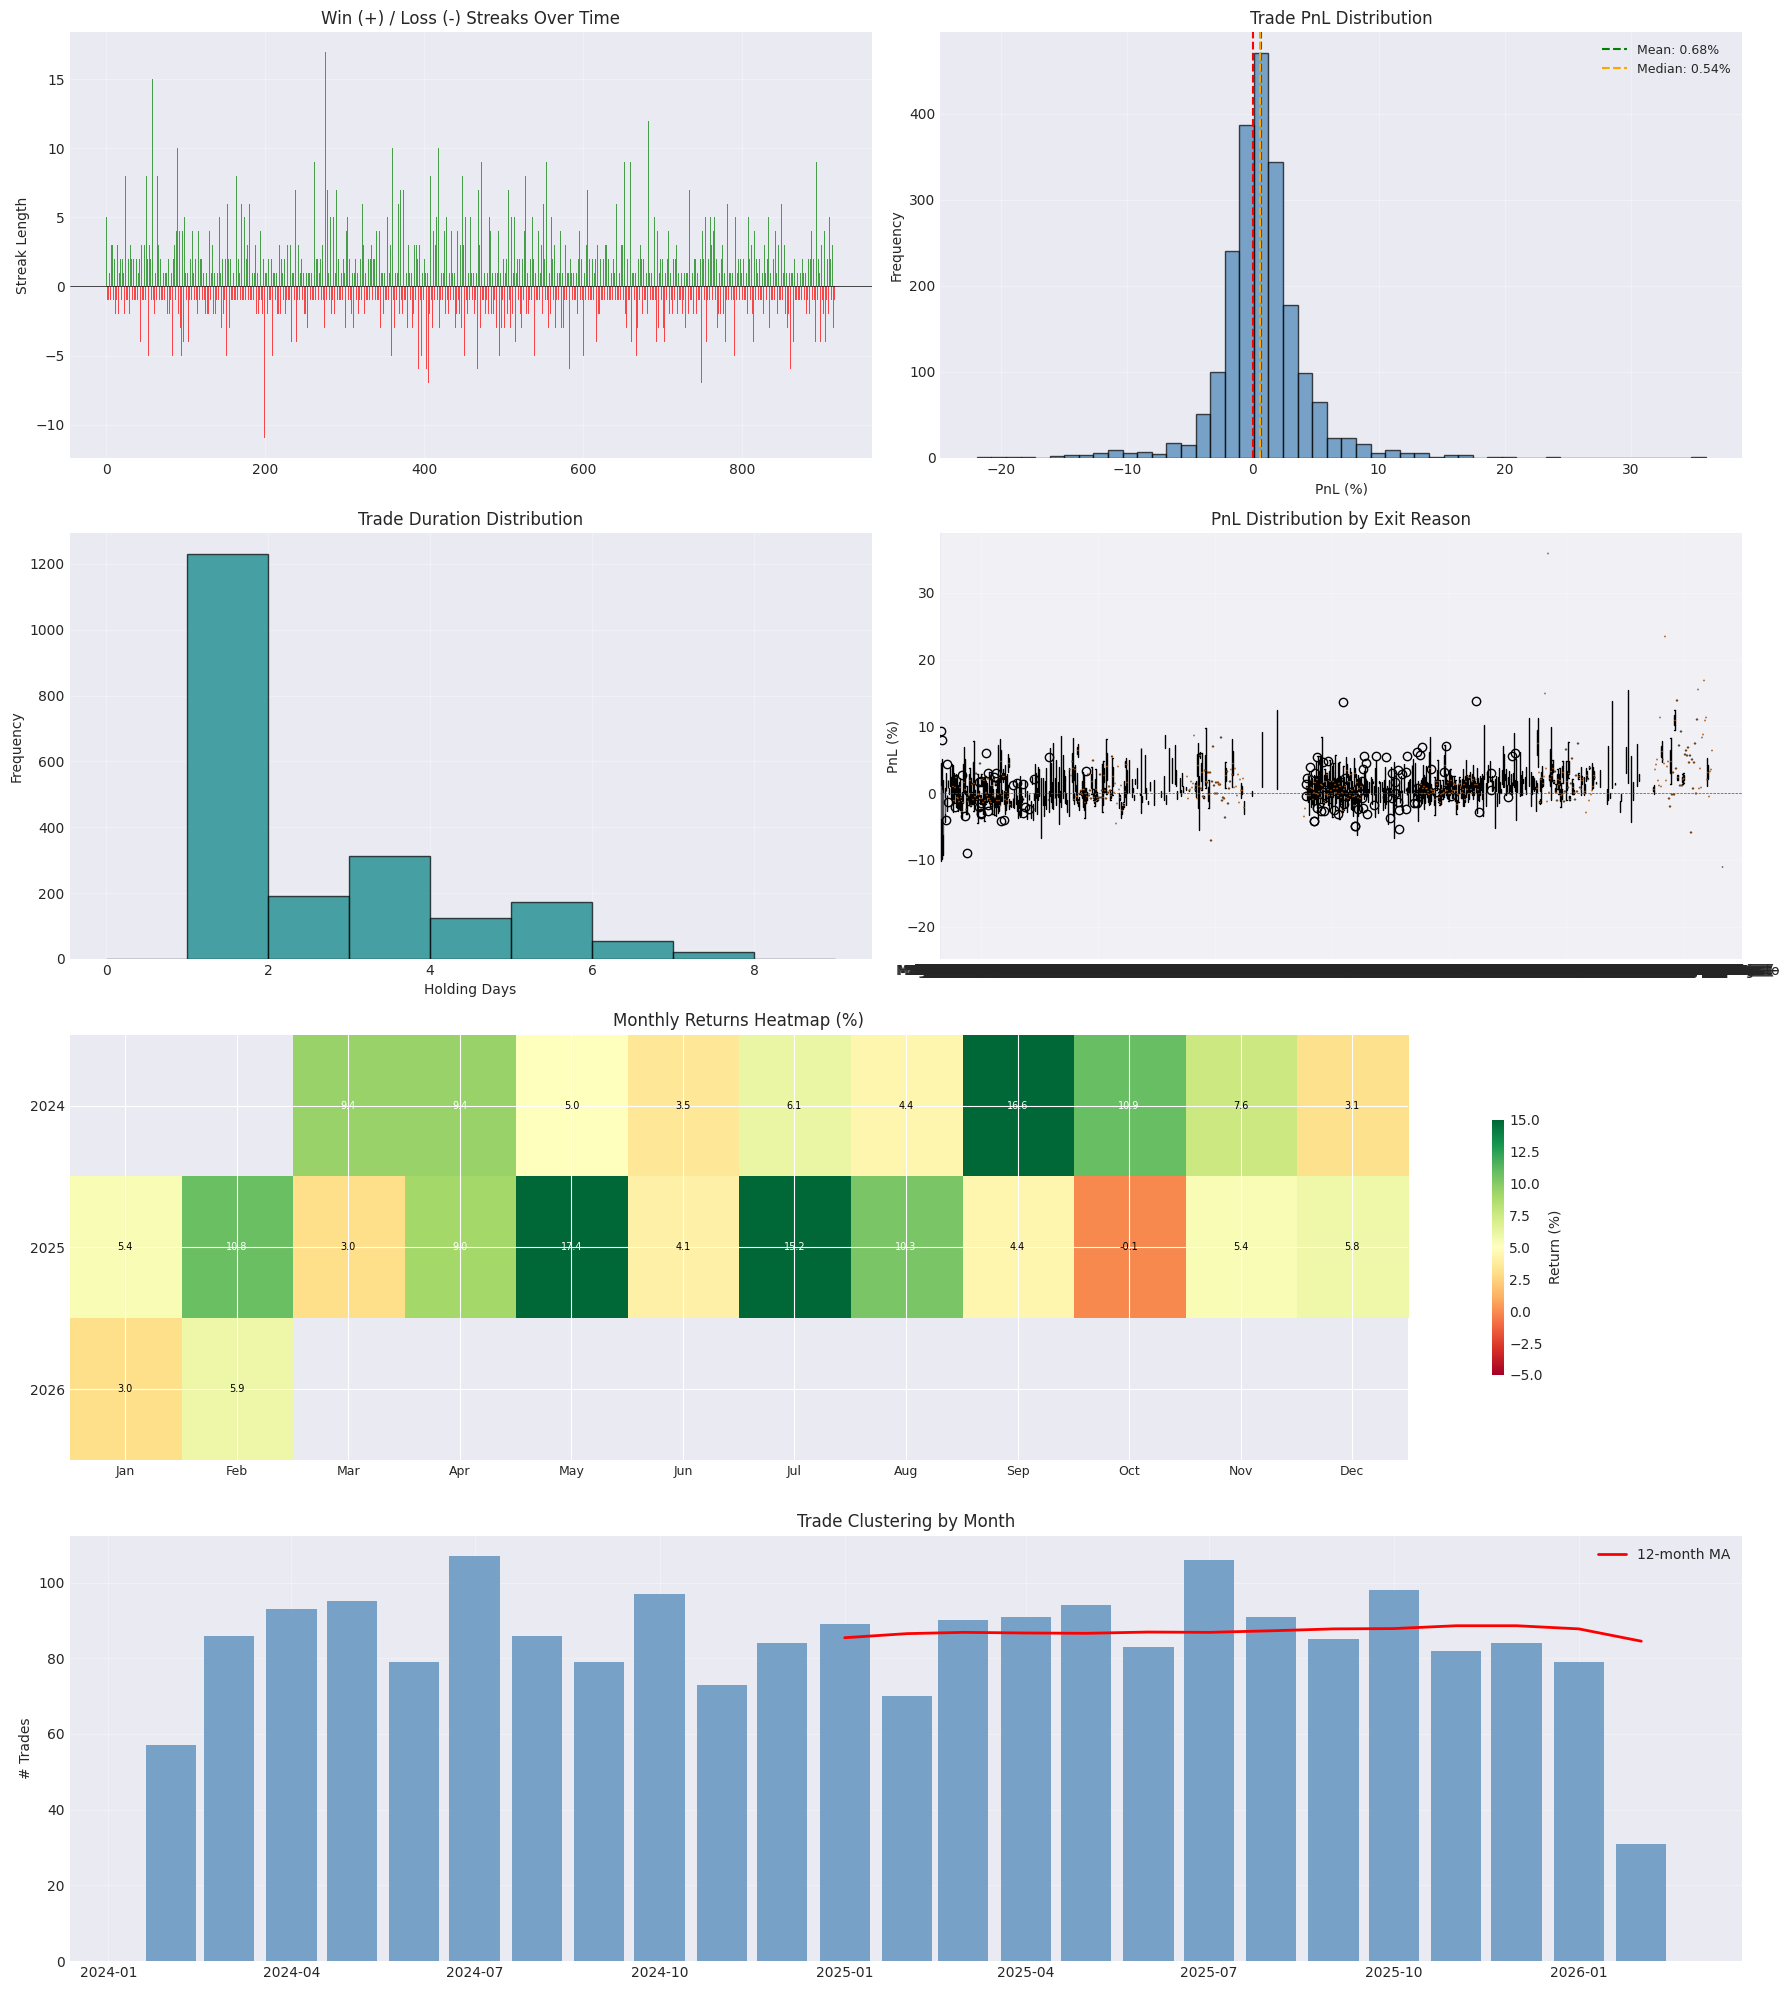

In [7]:
# 3B.3 — Trade-Level Analytics
if _show_bt:
    analytics.trade_analytics()
if _show_rp:
    replay_analytics.trade_analytics()

In [8]:
# 3B.4 — Turnover & Cost Analysis
if _show_bt:
    turnover_report = analytics.turnover_analysis()
if _show_rp:
    rp_turnover_report = replay_analytics.turnover_analysis()

3B.4 — TURNOVER & COST ANALYSIS [REPLAY]

--- Gross vs Net Returns ---
  Gross P&L (before costs):  $584,472
  Total commission+slippage: $0
  Net P&L (after costs):     $584,472
  Cost drag:                 0.00% of gross P&L
  Gross return:              584.5%
  Net return:                584.5%

--- Turnover ---
  Total traded value (round-trip): $184,953,833
  Avg portfolio value:             $295,359
  Annual turnover:                 313.72x
  Avg trades per year:             1057

--- Cost Efficiency ---
  Commission/Gross ratio:  0.00%
  Avg commission per trade: $0
  Commission rate:         0.20% per side

--- Break-Even Analysis ---
  Avg gross P&L per trade:  1.08%
  Break-even one-way cost:  0.54%
  Current one-way cost:     0.20%
  Safety margin:            0.34%  (2.7x current)

--- Slippage Sensitivity ---
    Slippage   Annual Return    Total Return         Net P&L
  ---------- --------------- --------------- ---------------
       0.05%          102.0%          307.0%

3B.5 — ENHANCED REGIME ANALYSIS [REPLAY]

Regime                                    Period  Trades     WR  AvgPnL   Return  Sharpe   MaxDD    VaR95 Exposure
------------------------------------------------------------------------------------------------------------------------
  2024 Bull               2024-01-01→2024-12-31     936  62.3%  +0.70% +129.10%   5.53   7.62% -1.1603%  129.68%
  2025-present            2025-01-01→2026-02-28    1173  60.2%  +0.66% +159.14%   3.95   6.96% -1.5780%  130.97%

Saved: /workspaces/Quant/DataAnalysisExpert/3B5_regime_analysis.png


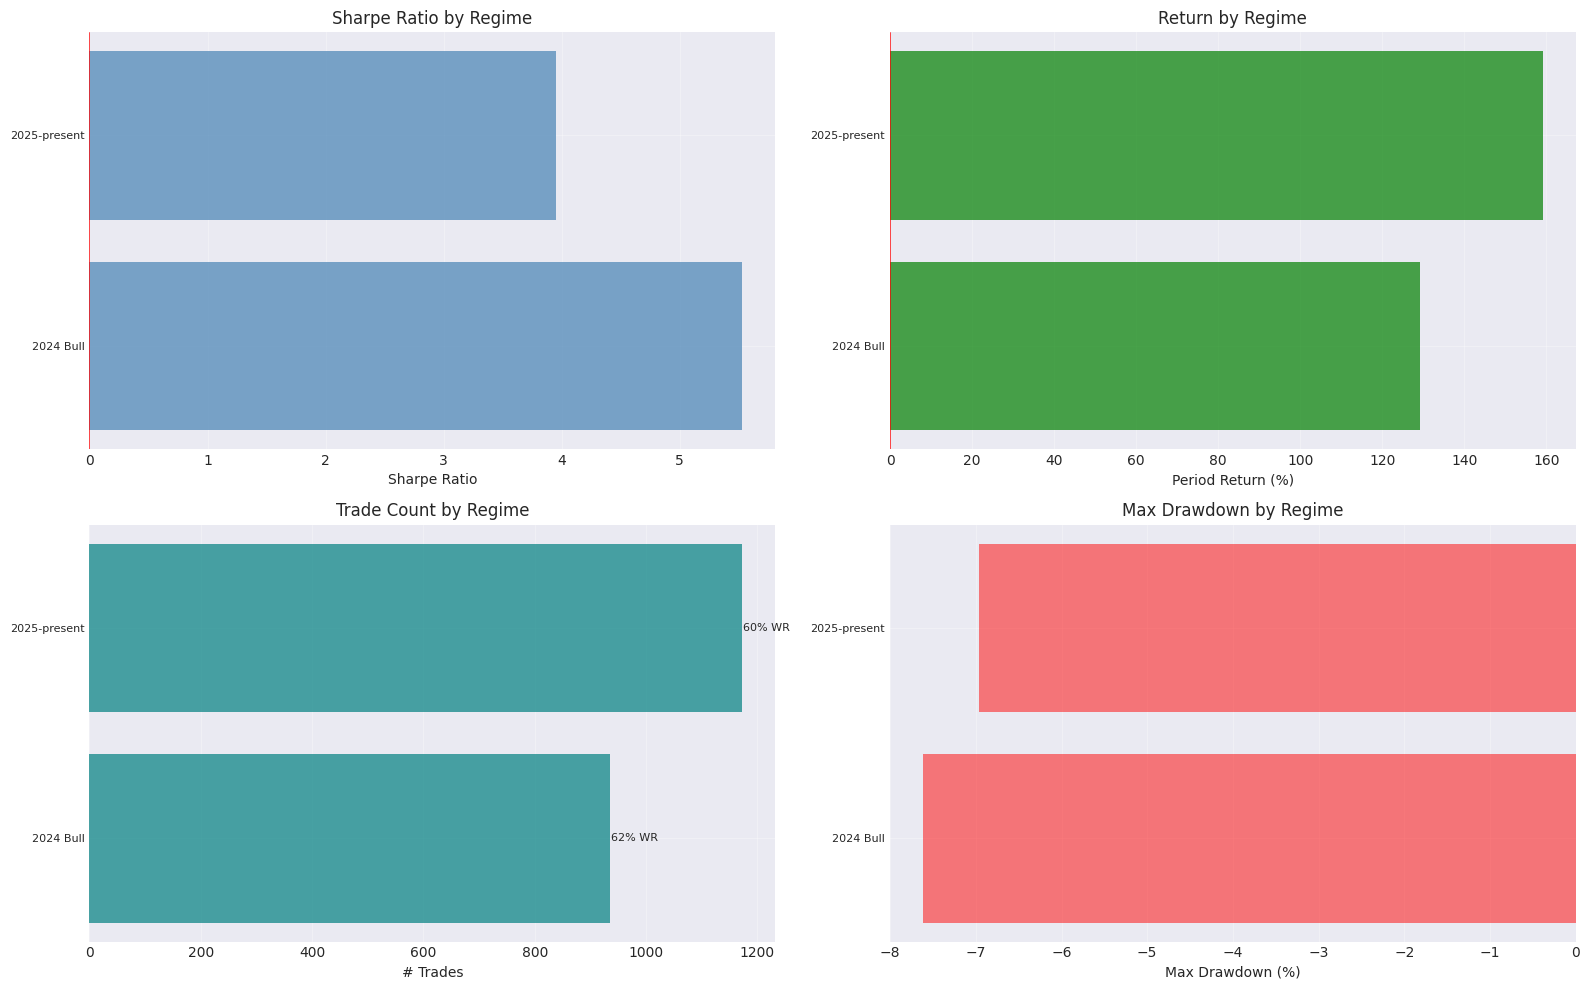


--- Key Regime Insights ---
  Best Sharpe:  2024 Bull (5.53)
  Worst Sharpe: 2025-present (3.95)
  All regimes profitable: Yes


In [9]:
# 3B.5 — Enhanced Regime Analysis
if _show_bt:
    regime_results = analytics.regime_analysis()
if _show_rp:
    rp_regime_results = replay_analytics.regime_analysis()

3B.6 — SECTOR / INDEX MEMBERSHIP ANALYSIS [REPLAY]

  Index            Symbols   Trades   Win Rate   Avg P&L%      Total P&L
  -----------------------------------------------------------------
  S&P 500               45      466      62.2%     +0.46% $      90,790
  NASDAQ-100            36      322      60.9%     +0.70% $      88,136
  Dow 30                12       97      55.7%     +0.05% $       7,513
  Russell 2000          45      618      60.8%     +0.59% $     144,628
  Other                 30      820      60.1%     +0.81% $     272,197

  Top 5 symbols by P&L:
    AFRM    $    59,888  (84 trades, 65% WR)
    ASGN    $    46,108  (42 trades, 74% WR)
    CELH    $    44,973  (40 trades, 72% WR)
    CRWD    $    28,202  (55 trades, 71% WR)
    DY      $    27,539  (42 trades, 76% WR)

  Bottom 5 symbols by P&L:
    LUMN    $   -25,666  (29 trades, 45% WR)
    HELE    $   -14,945  (6 trades, 33% WR)
    SANM    $    -8,628  (7 trades, 43% WR)
    CRS     $    -7,760  (7 trades, 

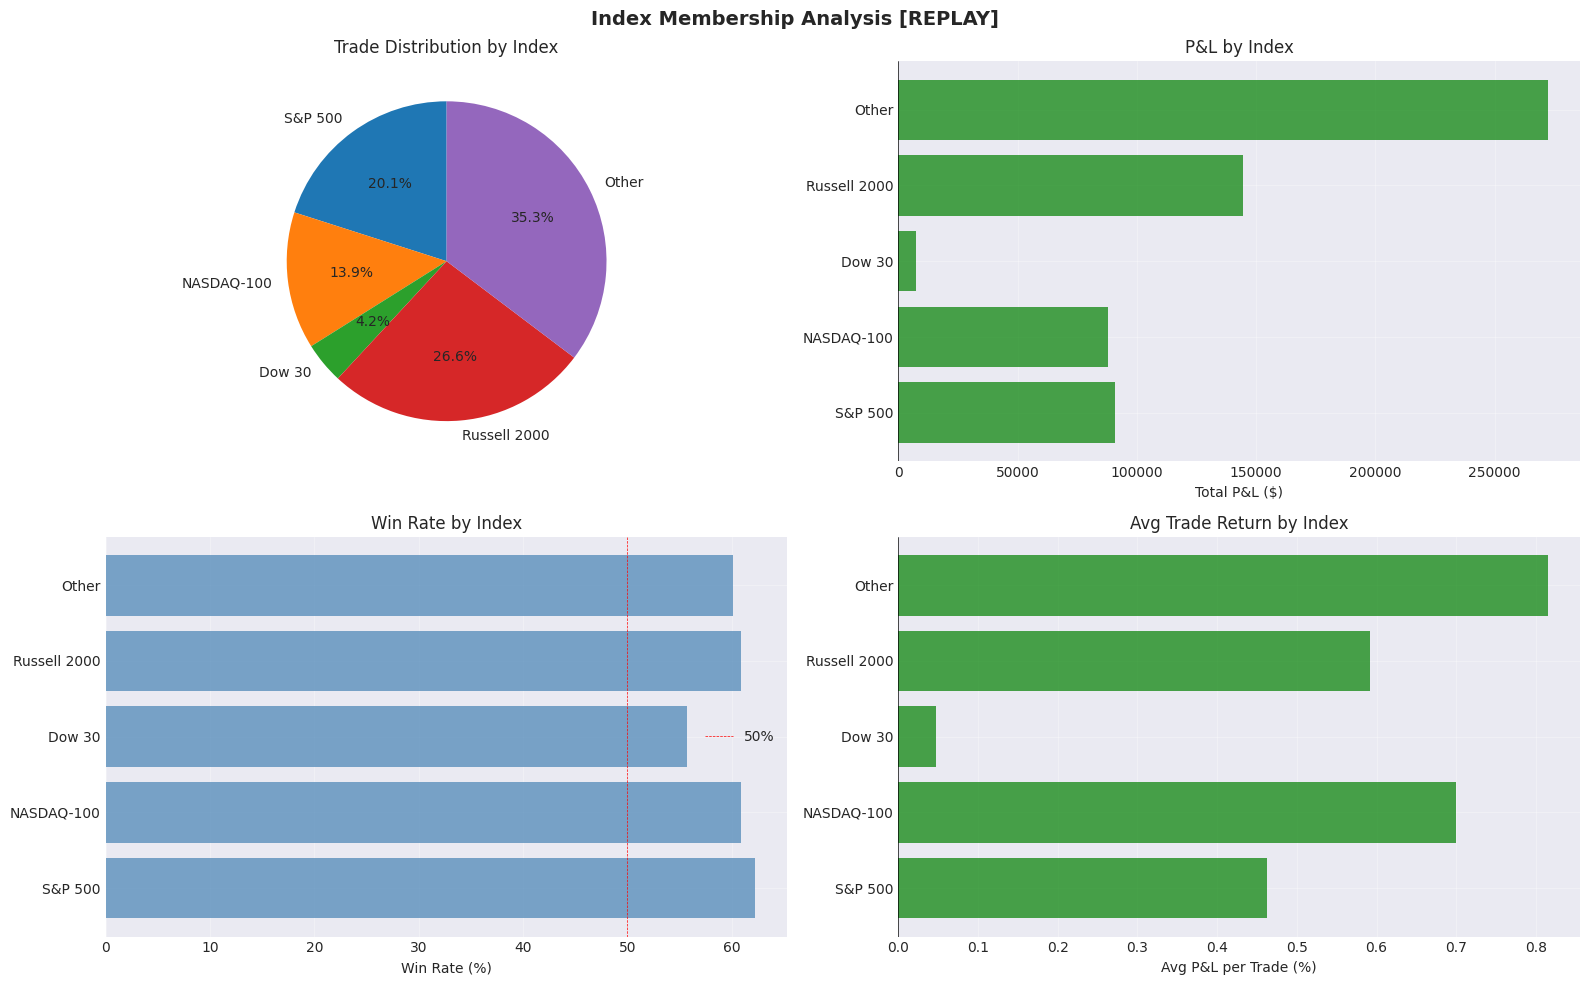

In [10]:
# 3B.6 — Sector / Index Membership Analysis
if _show_bt:
    sector_results = analytics.sector_analysis()
if _show_rp:
    rp_sector_results = replay_analytics.sector_analysis()


Saved: /workspaces/Quant/DataAnalysisExpert/3B7_slippage_sensitivity.png


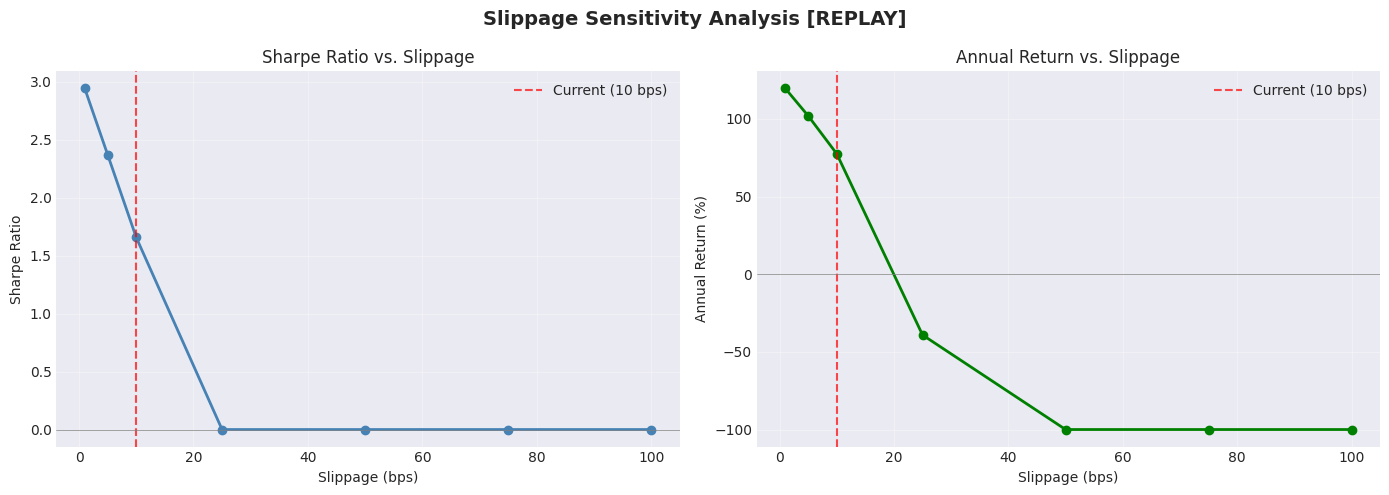

In [11]:
# 3B.7 — Slippage Sensitivity Visualization
if _show_bt:
    slip_df = analytics.slippage_sensitivity_chart()
if _show_rp:
    rp_slip_df = replay_analytics.slippage_sensitivity_chart()

3B.8 — TRADE VALIDATION [REPLAY]

  Total trades scanned: 2,109
  Flagged trades:       0

Saved: /workspaces/Quant/DataAnalysisExpert/3B8_trade_validation.png


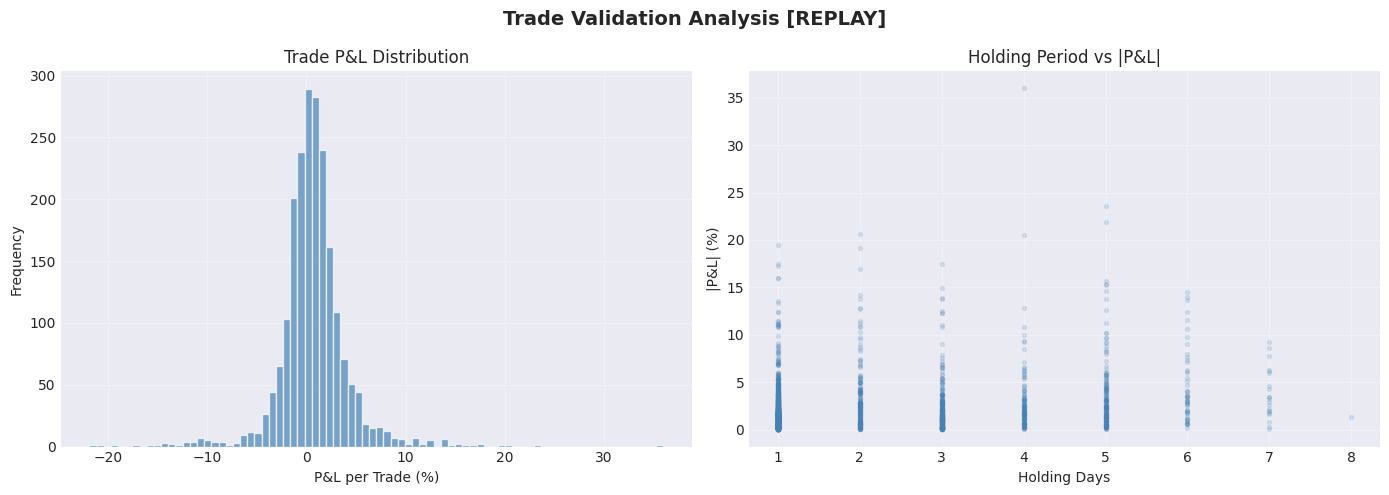

In [12]:
# 3B.8 — Trade Validation (Impossible Trade Detector)
if _show_bt:
    flagged_trades = analytics.trade_validation()
if _show_rp:
    rp_flagged_trades = replay_analytics.trade_validation()

In [13]:
# ============================================================================
# 3B.9 — DATA QUALITY AUDIT
# ============================================================================
# Checks: price jumps >20%, zero-volume days, duplicate dates, split artifacts
# Uses the already-loaded all_data dict — no redundant parquet re-reads.

import pandas as pd, numpy as np

quality_issues = []

for sym, df in all_data.items():
    if df is None or len(df) == 0:
        quality_issues.append({'symbol': sym, 'issue': 'empty_data', 'count': 1, 'detail': ''})
        continue

    # 1. Price jumps > 20% day-over-day
    if 'close' in df.columns and len(df) > 1:
        pct_change = df['close'].pct_change().abs()
        big_jumps = pct_change[pct_change > 0.20].dropna()
        if len(big_jumps) > 0:
            worst = big_jumps.idxmax()
            quality_issues.append({
                'symbol': sym, 'issue': 'price_jump_>20%',
                'count': len(big_jumps),
                'detail': f"worst={pct_change.loc[worst]:.1%} on {worst}",
            })

    # 2. Zero-volume days
    if 'volume' in df.columns:
        zero_vol = (df['volume'] == 0).sum()
        if zero_vol > 0:
            quality_issues.append({
                'symbol': sym, 'issue': 'zero_volume_days',
                'count': int(zero_vol),
                'detail': f"{zero_vol / len(df) * 100:.1f}% of days",
            })

    # 3. Duplicate dates
    if isinstance(df.index, pd.DatetimeIndex):
        dupes = df.index.duplicated().sum()
    elif 'date' in df.columns:
        dupes = df['date'].duplicated().sum()
    else:
        dupes = 0
    if dupes > 0:
        quality_issues.append({
            'symbol': sym, 'issue': 'duplicate_dates',
            'count': int(dupes), 'detail': '',
        })

    # 4. Suspicious sub-dollar prices (possible split artifact)
    if 'close' in df.columns:
        sub_dollar = (df['close'] < 1.0).sum()
        if sub_dollar > 5:
            quality_issues.append({
                'symbol': sym, 'issue': 'sub_dollar_prices',
                'count': int(sub_dollar),
                'detail': f"min=${df['close'].min():.2f}",
            })

quality_df = pd.DataFrame(quality_issues)

print("=" * 90)
print("3B.9 — DATA QUALITY AUDIT")
print("=" * 90)
print(f"\n  Symbols scanned:       {len(all_data)}")
print(f"  Symbols with issues:   {quality_df['symbol'].nunique() if len(quality_df) > 0 else 0}")
print(f"  Total flags:           {len(quality_df)}")

if len(quality_df) > 0:
    issue_summary = quality_df.groupby('issue').agg(
        symbols=('symbol', 'nunique'),
        total_count=('count', 'sum'),
    ).sort_values('symbols', ascending=False)
    print(f"\n  Issue Summary:")
    print(f"  {'Issue':<25s} {'Symbols':>8s} {'Total Count':>12s}")
    print(f"  {'-' * 45}")
    for iss, row in issue_summary.iterrows():
        print(f"  {iss:<25s} {row['symbols']:>8d} {row['total_count']:>12d}")

    # Show worst offenders
    worst = quality_df.sort_values('count', ascending=False).head(10)
    print(f"\n  Top 10 worst flags:")
    for _, r in worst.iterrows():
        print(f"    {r['symbol']:<6s} {r['issue']:<25s} count={r['count']:<5d} {r['detail']}")
else:
    print("\n  ✓ No data quality issues detected — all clean!")

3B.9 — DATA QUALITY AUDIT

  Symbols scanned:       294
  Symbols with issues:   197
  Total flags:           216

  Issue Summary:
  Issue                      Symbols  Total Count
  ---------------------------------------------
  price_jump_>20%                194          879
  zero_volume_days                17          390
  sub_dollar_prices                5         4686

  Top 10 worst flags:
    NVDA   sub_dollar_prices         count=2579  min=$0.15
    NFLX   sub_dollar_prices         count=1133  min=$0.23
    PATK   sub_dollar_prices         count=782   min=$0.07
    EXAS   sub_dollar_prices         count=126   min=$0.35
    PATK   zero_volume_days          count=123   2.4% of days
    PECO   zero_volume_days          count=87    7.0% of days
    PLAB   sub_dollar_prices         count=66    min=$0.35
    IESC   zero_volume_days          count=44    0.9% of days
    NOG    zero_volume_days          count=42    0.9% of days
    PATK   price_jump_>20%           count=41    worst

In [14]:
# ============================================================================
# 3B.10 — Backtest vs Replay Comparison
# ============================================================================
# Side-by-side analysis of backtest (vectorised) vs historical replay
# (event-driven) to validate strategy robustness under realistic execution.

from plotly.subplots import make_subplots
import numpy as np

if replay_results and 'error' not in replay_results:
    # ── Metrics Table ──
    print("=" * 70)
    print("  BACKTEST vs REPLAY COMPARISON")
    print("=" * 70)

    bt_return = results.total_return * 100
    rp_return = replay_results['total_return_pct']
    bt_sharpe = results.sharpe_ratio
    rp_sharpe = replay_results['sharpe_ratio']
    bt_dd     = results.max_drawdown * 100
    rp_dd     = replay_results['max_drawdown_pct']
    bt_wr     = results.win_rate * 100
    rp_wr     = replay_results['win_rate']
    bt_trades = results.total_trades
    rp_trades = replay_results['total_trades']
    bt_final  = results.equity_curve.iloc[-1] if len(results.equity_curve) > 0 else 0
    rp_final  = replay_results['final_equity']

    print(f"\n{'Metric':<25s} {'Backtest':>12s} {'Replay':>12s} {'Delta':>10s}")
    print("-" * 60)
    print(f"{'Total Return':<25s} {bt_return:>11.2f}% {rp_return:>11.2f}% {rp_return - bt_return:>+9.2f}%")
    print(f"{'Sharpe Ratio':<25s} {bt_sharpe:>12.2f} {rp_sharpe:>12.2f} {rp_sharpe - bt_sharpe:>+10.2f}")
    print(f"{'Max Drawdown':<25s} {bt_dd:>11.2f}% {rp_dd:>11.2f}% {rp_dd - bt_dd:>+9.2f}%")
    print(f"{'Win Rate':<25s} {bt_wr:>11.1f}% {rp_wr:>11.1f}% {rp_wr - bt_wr:>+9.1f}%")
    print(f"{'Total Trades':<25s} {bt_trades:>12d} {rp_trades:>12d} {rp_trades - bt_trades:>+10d}")
    print(f"{'Final Equity':<25s} ${bt_final:>11,.0f} ${rp_final:>11,.0f}")

    # ── 3-panel Visualization ──
    rp_eq = replay_results.get('equity_curve')
    bt_eq = results.equity_curve

    if rp_eq is not None and len(rp_eq) > 0:
        bt_eq_trim = bt_eq[bt_eq.index >= replay_start]

        if len(bt_eq_trim) > 0:
            # Normalize to base-100
            rp_norm = rp_eq / rp_eq.iloc[0] * 100
            bt_norm = bt_eq_trim / bt_eq_trim.iloc[0] * 100

            # Drawdowns
            rp_peak = rp_eq.cummax()
            rp_dd_s = (rp_eq - rp_peak) / rp_peak * 100
            bt_peak = bt_eq_trim.cummax()
            bt_dd_s = (bt_eq_trim - bt_peak) / bt_peak * 100

            # Daily returns
            rp_daily = rp_eq.pct_change().dropna() * 100
            bt_daily = bt_eq_trim.pct_change().dropna() * 100

            fig = make_subplots(
                rows=3, cols=1, shared_xaxes=True,
                row_heights=[0.45, 0.3, 0.25],
                vertical_spacing=0.06,
                subplot_titles=[
                    'Normalized Equity Curves (base=100)',
                    'Drawdown Comparison',
                    'Daily Return Distribution',
                ],
            )

            # Panel 1 — Equity overlay
            fig.add_trace(go.Scatter(
                x=bt_norm.index, y=bt_norm.values,
                mode='lines', name='Backtest',
                line=dict(color='#f0883e', width=2, dash='dot'),
            ), row=1, col=1)
            fig.add_trace(go.Scatter(
                x=rp_norm.index, y=rp_norm.values,
                mode='lines', name='Replay',
                line=dict(color='#667eea', width=2),
            ), row=1, col=1)

            # Panel 2 — Drawdowns
            fig.add_trace(go.Scatter(
                x=bt_dd_s.index, y=bt_dd_s.values,
                mode='lines', name='BT Drawdown',
                line=dict(color='#f0883e', width=1.5),
                fill='tozeroy', fillcolor='rgba(240,136,62,0.15)',
                showlegend=False,
            ), row=2, col=1)
            fig.add_trace(go.Scatter(
                x=rp_dd_s.index, y=rp_dd_s.values,
                mode='lines', name='RP Drawdown',
                line=dict(color='#667eea', width=1.5),
                fill='tozeroy', fillcolor='rgba(102,126,234,0.15)',
                showlegend=False,
            ), row=2, col=1)

            # Panel 3 — Return distributions
            fig.add_trace(go.Histogram(
                x=bt_daily.values, name='BT Returns',
                marker_color='rgba(240,136,62,0.6)',
                nbinsx=50, showlegend=False,
            ), row=3, col=1)
            fig.add_trace(go.Histogram(
                x=rp_daily.values, name='RP Returns',
                marker_color='rgba(102,126,234,0.6)',
                nbinsx=50, showlegend=False,
            ), row=3, col=1)

            fig.update_layout(
                height=800, autosize=True,
                template='plotly_dark',
                paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
                legend=dict(orientation='h', x=0, y=1.05),
                barmode='overlay',
                margin=dict(l=60, r=30, t=40, b=30),
            )
            fig.update_yaxes(title_text='Normalized Equity', row=1, col=1)
            fig.update_yaxes(title_text='Drawdown (%)', row=2, col=1)
            fig.update_yaxes(title_text='Frequency', row=3, col=1)
            fig.update_xaxes(title_text='Daily Return (%)', row=3, col=1)

            fig.show()
            plt.close('all')

            # Rolling correlation
            common_idx = rp_eq.index.intersection(bt_eq_trim.index)
            if len(common_idx) > 20:
                corr = np.corrcoef(
                    rp_eq.loc[common_idx].values,
                    bt_eq_trim.loc[common_idx].values,
                )[0, 1]
                print(f"\n  Equity curve correlation: {corr:.4f}")

    # Export replay trades
    if replay_results.get('trades_df') is not None and len(replay_results['trades_df']) > 0:
        export_path = project_root / 'data' / 'snapshots' / 'replay_trades.csv'
        replay_results['trades_df'].to_csv(export_path, index=False)
        print(f"\n📄 Trade log exported to: {export_path}")
else:
    print("⚠ Replay did not produce valid results — skipping comparison.")

# Free large replay objects after visualization
try:
    del replay_sim
except NameError:
    pass
import gc; gc.collect()

  BACKTEST vs REPLAY COMPARISON

Metric                        Backtest       Replay      Delta
------------------------------------------------------------
Total Return                 12339.13%      491.73% -11847.41%
Sharpe Ratio                      3.91         4.52      +0.61
Max Drawdown                     3.96%       -7.62%    -11.58%
Win Rate                         60.8%        61.1%      +0.3%
Total Trades                     23988         2109     -21879
Final Equity              $ 12,439,135 $    590,665



  Equity curve correlation: 0.9832

📄 Trade log exported to: /workspaces/Quant/data/snapshots/replay_trades.csv


28559

In [15]:
# ============================================================================
# PARITY TEST — Automated Backtest vs Replay Drift Detection
# ============================================================================
# Flags any metric where replay diverges from backtest by more than tolerance.
# Expected: small deltas because replay uses Option-D order flow (market+stop)
# while backtest uses flat slippage. Large deltas (>10%) indicate a code bug.

import numpy as np

PARITY_TOLERANCE = {
    'total_return_pct': 10.0,    # Allow up to 10% abs delta
    'sharpe_ratio':      0.5,    # Allow 0.5 abs delta
    'max_drawdown_pct':  5.0,    # Allow 5% abs delta
    'win_rate_pct':      5.0,    # Allow 5% abs delta
    'trade_count_pct':  15.0,    # Allow 15% relative delta in trade count
}

if replay_results and 'error' not in replay_results:
    print("=" * 80)
    print("  PARITY TEST — Backtest vs Replay Drift Detection")
    print("=" * 80)

    bt_return = results.total_return * 100
    rp_return = replay_results['total_return_pct']
    bt_sharpe = results.sharpe_ratio
    rp_sharpe = replay_results['sharpe_ratio']
    bt_dd     = results.max_drawdown * 100
    rp_dd     = replay_results['max_drawdown_pct']
    bt_wr     = results.win_rate * 100
    rp_wr     = replay_results['win_rate']
    bt_trades = results.total_trades
    rp_trades = replay_results['total_trades']

    checks = [
        ('Total Return',   abs(rp_return - bt_return),       PARITY_TOLERANCE['total_return_pct'],  f"{rp_return - bt_return:+.2f}%"),
        ('Sharpe Ratio',   abs(rp_sharpe - bt_sharpe),       PARITY_TOLERANCE['sharpe_ratio'],      f"{rp_sharpe - bt_sharpe:+.2f}"),
        ('Max Drawdown',   abs(rp_dd - bt_dd),               PARITY_TOLERANCE['max_drawdown_pct'],  f"{rp_dd - bt_dd:+.2f}%"),
        ('Win Rate',       abs(rp_wr - bt_wr),               PARITY_TOLERANCE['win_rate_pct'],       f"{rp_wr - bt_wr:+.1f}%"),
        ('Trade Count',    abs(rp_trades - bt_trades) / max(bt_trades, 1) * 100,
                           PARITY_TOLERANCE['trade_count_pct'], f"{rp_trades - bt_trades:+d} ({(rp_trades - bt_trades) / max(bt_trades,1) * 100:+.1f}%)"),
    ]

    print(f"\n  {'Metric':<18s} {'Delta':>14s} {'Tolerance':>12s} {'Status':>8s}")
    print(f"  {'-' * 55}")

    n_pass = 0
    for name, delta, tol, delta_str in checks:
        status = '✓ PASS' if delta <= tol else '✗ FAIL'
        if delta <= tol:
            n_pass += 1
        print(f"  {name:<18s} {delta_str:>14s} {f'±{tol:.1f}':>12s} {status:>8s}")

    print(f"\n  Result: {n_pass}/{len(checks)} checks passed", end='')
    if n_pass == len(checks):
        print(" — Replay is in parity with backtest ✓")
    else:
        print(" — DRIFT DETECTED. Investigate divergent metrics.")
        print("  Note: Some drift is expected — replay uses Option-D order flow")
        print("        (market entry → GTC stop) while backtest uses flat slippage.")

    # Equity correlation
    if replay_results.get('equity_curve') is not None:
        rp_eq = replay_results['equity_curve']
        bt_eq = results.equity_curve
        bt_eq_trim = bt_eq[bt_eq.index >= replay_start]
        common_index = rp_eq.index.intersection(bt_eq_trim.index)
        if len(common_index) > 10:
            corr = np.corrcoef(rp_eq.loc[common_index].values, bt_eq_trim.loc[common_index].values)[0, 1]
            print(f"\n  Equity curve correlation: {corr:.4f}")
else:
    print("⚠ Replay results not available — skipping parity test.")

  PARITY TEST — Backtest vs Replay Drift Detection

  Metric                      Delta    Tolerance   Status
  -------------------------------------------------------
  Total Return           -11847.41%        ±10.0   ✗ FAIL
  Sharpe Ratio                +0.61         ±0.5   ✗ FAIL
  Max Drawdown              -11.58%         ±5.0   ✗ FAIL
  Win Rate                    +0.3%         ±5.0   ✓ PASS
  Trade Count        -21879 (-91.2%)        ±15.0   ✗ FAIL

  Result: 1/5 checks passed — DRIFT DETECTED. Investigate divergent metrics.
  Note: Some drift is expected — replay uses Option-D order flow
        (market entry → GTC stop) while backtest uses flat slippage.

  Equity curve correlation: 0.9832
